# 15 — SHARP-only Temporal Baseline from Fusion Manifest

**Purpose.** This notebook trains the first magnetic-field branch baseline for the multimodal AIA + SHARP + GOES framework.

It uses the fusion alignment manifest created in Notebook 14, but it trains **SHARP-only** models.

## Scientific framing

This is still a **Solar Cycle 24-only** experiment. The folds cover 2010–2015 and should be described as within-cycle chronological/regime testing, not Cycle 24 → Cycle 25 generalisation.

## Modality rule

- **AIA:** used only for sample identity and alignment at this stage; no image pixels are used.
- **SHARP:** used as the model input branch.
- **GOES:** used only through the official AR-specific target label `label_48h_final`; no GOES/XRS input features are used in this notebook.

## Feature views

This notebook evaluates:

1. Current-time SHARP snapshot.
2. 6h SHARP temporal aggregates.
3. 12h SHARP temporal aggregates.
4. 24h SHARP temporal aggregates as a sensitivity check.

48h temporal SHARP is not used as an official first baseline because Notebook 14 showed only about 29% sequence coverage.

## Evaluation protocol

For each chronological fold:

- train on earlier years;
- validate on the year immediately before the test year;
- select decision threshold by validation TSS;
- apply the selected threshold unchanged to the held-out test year.

Test-set diagnostic best thresholds are **not** used for official reporting.


In [1]:
from pathlib import Path
import json
from datetime import datetime
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / ".git").exists() and (p / "training").exists():
            return p
    for p in candidates:
        if (p / "training").exists() and (p / "results").exists():
            return p
    raise RuntimeError("Could not find project root. Run from inside the solar-flare-aia-training repo.")

ROOT = find_project_root()
TRAINING_DIR = ROOT / "training"
FUSION_DIR = TRAINING_DIR / "fusion_manifests"
METRICS_DIR = ROOT / "results" / "metrics"
FIG_DIR = ROOT / "results" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("FUSION_DIR:", FUSION_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("Started:", datetime.now().isoformat(timespec="seconds"))


ROOT: /Users/mac/Projects/solar-flare-aia-training
FUSION_DIR: /Users/mac/Projects/solar-flare-aia-training/training/fusion_manifests
METRICS_DIR: /Users/mac/Projects/solar-flare-aia-training/results/metrics
Started: 2026-08-03T17:41:18


## 1. Configuration

In [2]:
ALIGNMENT_MANIFEST = FUSION_DIR / "aia_sharp_goes_fusion_alignment_manifest_2010_2016.csv"

LABEL_COL = "official_label_48h_final"

PREFERRED_SHARP_FEATURES_16 = [
    "MEANGBZ", "MEANGAM", "MEANGBT", "MEANGBH",
    "MEANJZD", "TOTUSJZ", "MEANALP", "MEANJZH",
    "ABSNJZH", "SAVNCPP", "MEANSHR", "SHRGT45",
    "R_VALUE", "USFLUX", "TOTPOT", "TOTUSJH",
]
OPTIONAL_SHARP_FEATURES = ["MEANPOT", "AREA_ACR"]

TEMPORAL_WINDOWS_HOURS = [6, 12, 24]
CADENCE_MINUTES = 96

FOLD_SPECS = {
    "test_2013": {"train_years": [2010, 2011], "val_years": [2012], "test_years": [2013]},
    "test_2014": {"train_years": [2010, 2011, 2012], "val_years": [2013], "test_years": [2014]},
    "test_2015": {"train_years": [2010, 2011, 2012, 2013], "val_years": [2014], "test_years": [2015]},
}

RANDOM_STATE = 42
THRESHOLDS = np.linspace(0.0, 1.0, 401)

RUN_RANDOM_FOREST = True
RF_N_ESTIMATORS = 150
RF_MAX_DEPTH = 12
RF_MIN_SAMPLES_LEAF = 10

if not ALIGNMENT_MANIFEST.exists():
    raise FileNotFoundError(f"Missing alignment manifest: {ALIGNMENT_MANIFEST}")

print("Alignment manifest:", ALIGNMENT_MANIFEST)
print("RUN_RANDOM_FOREST:", RUN_RANDOM_FOREST)


Alignment manifest: /Users/mac/Projects/solar-flare-aia-training/training/fusion_manifests/aia_sharp_goes_fusion_alignment_manifest_2010_2016.csv
RUN_RANDOM_FOREST: True


## 2. Load fusion alignment manifest

In [3]:
aligned = pd.read_csv(ALIGNMENT_MANIFEST, parse_dates=["T_REC_dt"])

for c in ["sample_id", "gcp_path", "file"]:
    if c in aligned.columns:
        aligned[c] = aligned[c].astype(str)

for c in ["HARPNUM", "NOAA_AR_clean", "year"]:
    if c in aligned.columns:
        aligned[c] = pd.to_numeric(aligned[c], errors="coerce").astype("Int64")

aligned[LABEL_COL] = pd.to_numeric(aligned[LABEL_COL], errors="coerce")
aligned = aligned.dropna(subset=["sample_id", "T_REC_dt", "HARPNUM", "year", LABEL_COL]).copy()
aligned[LABEL_COL] = aligned[LABEL_COL].astype(int)

print("Aligned rows after basic required fields:", aligned.shape)
print("Years:", sorted(aligned["year"].dropna().astype(int).unique().tolist()))
print("Positives:", int(aligned[LABEL_COL].sum()))
print("Negatives:", int((aligned[LABEL_COL] == 0).sum()))
display(aligned.head(3))


Aligned rows after basic required fields: (68010, 56)
Years: [2010, 2011, 2012, 2013, 2014, 2015, 2016]
Positives: 2398
Negatives: 65612


,sample_id,gcp_path,file,T_REC_dt,HARPNUM,NOAA_AR_clean,year,label_48h_global_old,label_48h_ar_specific,label_48h_final,...,sample_id_merge_status,has_sharp_row,has_aia_npz_path,aia_sharp_time_delta_seconds,harpnum_match,noaa_ar_match,label_match_aia_vs_sharp,official_label_48h_final,goes_label_lineage_status,goes_input_feature_status
0,20100521_1636_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1636_HARP26_NOAA11072.npz,2010-05-21 16:36:00,26,11072,2010,0,0,0,...,both,True,True,0.0,True,True,True,0,goes_flare_catalog_used_for_ar_specific_future...,not_yet_available_as_input_feature_table
1,20100521_1812_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1812_HARP26_NOAA11072.npz,2010-05-21 18:12:00,26,11072,2010,0,0,0,...,both,True,True,0.0,True,True,True,0,goes_flare_catalog_used_for_ar_specific_future...,not_yet_available_as_input_feature_table
2,20100521_1948_HARP26_NOAA11072,gs://suryabench-sharp-pipeline-bamidele/sample...,20100521_1948_HARP26_NOAA11072.npz,2010-05-21 19:48:00,26,11072,2010,0,0,0,...,both,True,True,0.0,True,True,True,0,goes_flare_catalog_used_for_ar_specific_future...,not_yet_available_as_input_feature_table


## 3. Confirm SHARP feature availability

In [4]:
available_preferred = [f"sharp_{f}" for f in PREFERRED_SHARP_FEATURES_16 if f"sharp_{f}" in aligned.columns]
missing_preferred = [f for f in PREFERRED_SHARP_FEATURES_16 if f"sharp_{f}" not in aligned.columns]
available_optional = [f"sharp_{f}" for f in OPTIONAL_SHARP_FEATURES if f"sharp_{f}" in aligned.columns]

feature_audit = pd.DataFrame([
    {
        "feature": f,
        "expected_column": f"sharp_{f}",
        "feature_group": "preferred_16",
        "available": f"sharp_{f}" in aligned.columns,
        "missing_rate": float(aligned[f"sharp_{f}"].isna().mean()) if f"sharp_{f}" in aligned.columns else np.nan,
    }
    for f in PREFERRED_SHARP_FEATURES_16
] + [
    {
        "feature": f,
        "expected_column": f"sharp_{f}",
        "feature_group": "optional",
        "available": f"sharp_{f}" in aligned.columns,
        "missing_rate": float(aligned[f"sharp_{f}"].isna().mean()) if f"sharp_{f}" in aligned.columns else np.nan,
    }
    for f in OPTIONAL_SHARP_FEATURES
])

feature_audit_path = METRICS_DIR / "sharp_temporal_baseline_feature_audit.csv"
feature_audit.to_csv(feature_audit_path, index=False)

print("Available preferred SHARP columns:", available_preferred)
print("Missing preferred SHARP features:", missing_preferred)
print("Available optional SHARP columns:", available_optional)
print("Saved:", feature_audit_path)
display(feature_audit)


Available preferred SHARP columns: ['sharp_MEANGBZ', 'sharp_MEANGAM', 'sharp_MEANGBT', 'sharp_MEANGBH', 'sharp_MEANJZD', 'sharp_TOTUSJZ', 'sharp_MEANALP', 'sharp_MEANJZH', 'sharp_ABSNJZH', 'sharp_SAVNCPP', 'sharp_MEANSHR', 'sharp_SHRGT45', 'sharp_R_VALUE', 'sharp_USFLUX', 'sharp_TOTPOT']
Missing preferred SHARP features: ['TOTUSJH']
Available optional SHARP columns: ['sharp_MEANPOT', 'sharp_AREA_ACR']
Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_feature_audit.csv


,feature,expected_column,feature_group,available,missing_rate
0,MEANGBZ,sharp_MEANGBZ,preferred_16,True,0.000603
1,MEANGAM,sharp_MEANGAM,preferred_16,True,0.000647
2,MEANGBT,sharp_MEANGBT,preferred_16,True,0.000603
3,MEANGBH,sharp_MEANGBH,preferred_16,True,0.000603
4,MEANJZD,sharp_MEANJZD,preferred_16,True,0.000603
5,TOTUSJZ,sharp_TOTUSJZ,preferred_16,True,0.000000
6,MEANALP,sharp_MEANALP,preferred_16,True,0.000603
7,MEANJZH,sharp_MEANJZH,preferred_16,True,0.000603
8,ABSNJZH,sharp_ABSNJZH,preferred_16,True,0.000000
9,SAVNCPP,sharp_SAVNCPP,preferred_16,True,0.000000


## 4. Build temporal aggregate features

In [5]:
def build_temporal_aggregates(df, feature_cols, hours, cadence_minutes=96):
    """Build past-window SHARP aggregate features per HARPNUM, inclusive of issue time.

    For each sample at time t, only SHARP rows for the same HARPNUM with
    t - lookback <= time <= t are used. This is leakage-safe because it never
    looks after the issue time.
    """
    key_cols = ["sample_id", "HARPNUM", "T_REC_dt"]
    work = df[key_cols + feature_cols].copy()
    work["HARPNUM"] = pd.to_numeric(work["HARPNUM"], errors="coerce").astype("Int64")
    work["T_REC_dt"] = pd.to_datetime(work["T_REC_dt"], errors="coerce")
    work = work.dropna(subset=["HARPNUM", "T_REC_dt"]).sort_values(["HARPNUM", "T_REC_dt"]).reset_index(drop=True)
    work["t_ns"] = work["T_REC_dt"].astype("int64")

    expected_steps = int(np.floor((hours * 60) / cadence_minutes)) + 1
    output_rows = []
    prefix = f"sharp_{hours}h"

    for harp, sub in work.groupby("HARPNUM", sort=False):
        times = sub["t_ns"].to_numpy()
        values = sub[feature_cols].to_numpy(dtype=float)
        sample_ids = sub["sample_id"].to_numpy()

        for i, t in enumerate(times):
            start = t - int(hours * 3600 * 1_000_000_000)
            left = np.searchsorted(times, start, side="left")
            right = i + 1
            window = values[left:right]

            row = {"sample_id": sample_ids[i], f"{prefix}_history_count": int(window.shape[0])}
            for j, col in enumerate(feature_cols):
                base = col.replace("sharp_", "")
                x = window[:, j]
                if np.all(np.isnan(x)):
                    row[f"{prefix}_{base}_last"] = np.nan
                    row[f"{prefix}_{base}_mean"] = np.nan
                    row[f"{prefix}_{base}_std"] = np.nan
                    row[f"{prefix}_{base}_min"] = np.nan
                    row[f"{prefix}_{base}_max"] = np.nan
                    row[f"{prefix}_{base}_delta"] = np.nan
                else:
                    row[f"{prefix}_{base}_last"] = x[-1]
                    row[f"{prefix}_{base}_mean"] = np.nanmean(x)
                    row[f"{prefix}_{base}_std"] = np.nanstd(x)
                    row[f"{prefix}_{base}_min"] = np.nanmin(x)
                    row[f"{prefix}_{base}_max"] = np.nanmax(x)
                    row[f"{prefix}_{base}_delta"] = x[-1] - x[0]
            output_rows.append(row)

    out = pd.DataFrame(output_rows)
    out[f"{prefix}_expected_steps"] = expected_steps
    out[f"{prefix}_meets_min_history"] = out[f"{prefix}_history_count"] >= expected_steps
    return out

base_cols = ["sample_id", "T_REC_dt", "HARPNUM", "NOAA_AR_clean", "year", LABEL_COL, "gcp_path"]
base_cols = [c for c in base_cols if c in aligned.columns]

feature_views = {}

snapshot15_cols = available_preferred.copy()
feature_views["snapshot_available_preferred"] = {
    "df": aligned[base_cols + snapshot15_cols].copy(),
    "features": snapshot15_cols,
    "history_filter_col": None,
    "description": "Current-time available preferred SHARP features; missing preferred features are excluded but audited.",
}

if available_optional:
    snapshot_optional_cols = available_preferred + available_optional
    feature_views["snapshot_plus_optional"] = {
        "df": aligned[base_cols + snapshot_optional_cols].copy(),
        "features": snapshot_optional_cols,
        "history_filter_col": None,
        "description": "Current-time available preferred SHARP features plus optional MEANPOT/AREA_ACR if present.",
    }

temporal_feature_base = available_preferred.copy()
for hours in TEMPORAL_WINDOWS_HOURS:
    print(f"Building {hours}h temporal aggregates for {len(temporal_feature_base)} SHARP features...")
    agg = build_temporal_aggregates(aligned, temporal_feature_base, hours, cadence_minutes=CADENCE_MINUTES)
    view = aligned[base_cols].merge(agg, on="sample_id", how="left")
    prefix = f"sharp_{hours}h"
    temporal_cols = [
        c for c in view.columns
        if c.startswith(prefix + "_")
        and not c.endswith("_meets_min_history")
        and not c.endswith("_expected_steps")
        and not c.endswith("_history_count")
    ]
    temporal_cols += [f"{prefix}_history_count"]
    feature_views[f"temporal_{hours}h_available_preferred"] = {
        "df": view,
        "features": temporal_cols,
        "history_filter_col": f"{prefix}_meets_min_history",
        "description": f"Past {hours}h leakage-safe aggregate SHARP features for available preferred feature set.",
    }

view_rows = []
for name, obj in feature_views.items():
    d = obj["df"]
    filt = obj["history_filter_col"]
    usable = d if filt is None else d[d[filt].fillna(False)]
    view_rows.append({
        "feature_view": name,
        "description": obj["description"],
        "n_features": len(obj["features"]),
        "rows_before_history_filter": len(d),
        "rows_after_history_filter": len(usable),
        "coverage_rate": len(usable) / len(d),
        "positives_after_filter": int(usable[LABEL_COL].sum()),
        "positive_rate_after_filter": float(usable[LABEL_COL].mean()),
    })

feature_view_summary = pd.DataFrame(view_rows)
feature_view_summary_path = METRICS_DIR / "sharp_temporal_baseline_feature_view_summary.csv"
feature_view_summary.to_csv(feature_view_summary_path, index=False)

print("Saved:", feature_view_summary_path)
display(feature_view_summary)


Building 6h temporal aggregates for 15 SHARP features...


Building 12h temporal aggregates for 15 SHARP features...


Building 24h temporal aggregates for 15 SHARP features...


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_feature_view_summary.csv


,feature_view,description,n_features,rows_before_history_filter,rows_after_history_filter,coverage_rate,positives_after_filter,positive_rate_after_filter
0,snapshot_available_preferred,Current-time available preferred SHARP feature...,15,68010,68010,1.000000,2398,0.035260
1,snapshot_plus_optional,Current-time available preferred SHARP feature...,17,68010,68010,1.000000,2398,0.035260
2,temporal_6h_available_preferred,Past 6h leakage-safe aggregate SHARP features ...,91,68010,62219,0.914851,2182,0.035070
3,temporal_12h_available_preferred,Past 12h leakage-safe aggregate SHARP features...,91,68010,54638,0.803382,1892,0.034628
4,temporal_24h_available_preferred,Past 24h leakage-safe aggregate SHARP features...,91,68010,35626,0.523835,1062,0.029810


## 5. Evaluation utilities

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, precision_score, f1_score, confusion_matrix
)

def hss_score(tp, tn, fp, fn):
    den = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    if den == 0:
        return np.nan
    return 2 * (tp * tn - fp * fn) / den

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    tss = recall + specificity - 1 if not (pd.isna(recall) or pd.isna(specificity)) else np.nan
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tss": tss,
        "hss": hss_score(tp, tn, fp, fn),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }

def ranking_metrics(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    out = {}
    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan
    out["brier"] = brier_score_loss(y_true, np.clip(y_prob, 0, 1))
    return out

def make_threshold_grid(y_true, y_prob, thresholds=THRESHOLDS):
    rows = []
    for th in thresholds:
        rows.append(metrics_at_threshold(y_true, y_prob, th))
    return pd.DataFrame(rows)

def select_threshold_by_val_tss(y_true, y_prob):
    grid = make_threshold_grid(y_true, y_prob)
    selected = grid.sort_values(["tss", "hss", "f1"], ascending=[False, False, False]).iloc[0]
    return float(selected["threshold"]), grid

def make_model(model_name):
    if model_name == "logistic_regression_balanced":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ])
    if model_name == "random_forest_balanced":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=RF_N_ESTIMATORS,
                max_depth=RF_MAX_DEPTH,
                min_samples_leaf=RF_MIN_SAMPLES_LEAF,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ])
    raise ValueError(f"Unknown model: {model_name}")

def predict_proba_positive(model, X):
    return model.predict_proba(X)[:, 1]


## 6. Train SHARP-only baselines

In [7]:
models_to_run = ["logistic_regression_balanced"]
if RUN_RANDOM_FOREST:
    models_to_run.append("random_forest_balanced")

result_rows = []
prediction_rows = []
threshold_grid_rows = []
fold_data_rows = []

for view_name, view_obj in feature_views.items():
    view_df = view_obj["df"].copy()
    feature_cols = view_obj["features"]
    history_filter_col = view_obj["history_filter_col"]

    if history_filter_col is not None:
        view_df = view_df[view_df[history_filter_col].fillna(False)].copy()

    view_df = view_df.dropna(subset=["year", LABEL_COL]).copy()
    view_df["year"] = view_df["year"].astype(int)
    view_df[LABEL_COL] = view_df[LABEL_COL].astype(int)

    for fold_id, spec in FOLD_SPECS.items():
        train = view_df[view_df["year"].isin(spec["train_years"])].copy()
        val = view_df[view_df["year"].isin(spec["val_years"])].copy()
        test = view_df[view_df["year"].isin(spec["test_years"])].copy()

        fold_data_rows.append({
            "feature_view": view_name,
            "fold_id": fold_id,
            "train_rows": len(train),
            "val_rows": len(val),
            "test_rows": len(test),
            "train_positives": int(train[LABEL_COL].sum()) if len(train) else 0,
            "val_positives": int(val[LABEL_COL].sum()) if len(val) else 0,
            "test_positives": int(test[LABEL_COL].sum()) if len(test) else 0,
            "n_features": len(feature_cols),
            "history_filter_col": history_filter_col,
        })

        if min(len(train), len(val), len(test)) == 0:
            print("Skipping empty split:", view_name, fold_id)
            continue
        if train[LABEL_COL].nunique() < 2 or val[LABEL_COL].nunique() < 2 or test[LABEL_COL].nunique() < 2:
            print("Skipping one-class split:", view_name, fold_id)
            continue

        X_train, y_train = train[feature_cols], train[LABEL_COL].to_numpy()
        X_val, y_val = val[feature_cols], val[LABEL_COL].to_numpy()
        X_test, y_test = test[feature_cols], test[LABEL_COL].to_numpy()

        for model_name in models_to_run:
            print(f"Training {model_name} | {view_name} | {fold_id} | train={len(train)} val={len(val)} test={len(test)} features={len(feature_cols)}")
            model = make_model(model_name)
            model.fit(X_train, y_train)

            val_prob = predict_proba_positive(model, X_val)
            test_prob = predict_proba_positive(model, X_test)

            selected_threshold, val_grid = select_threshold_by_val_tss(y_val, val_prob)
            test_grid = make_threshold_grid(y_test, test_prob)
            diagnostic_best_test = test_grid.sort_values(["tss", "hss", "f1"], ascending=[False, False, False]).iloc[0]

            val_rank = ranking_metrics(y_val, val_prob)
            test_rank = ranking_metrics(y_test, test_prob)
            val_at = metrics_at_threshold(y_val, val_prob, selected_threshold)
            test_at = metrics_at_threshold(y_test, test_prob, selected_threshold)

            row = {
                "experiment": "sharp_temporal_baseline_from_fusion_manifest",
                "modality": "SHARP_only",
                "goes_usage": "label_lineage_only_no_goes_input_features",
                "solar_cycle_scope": "Solar_Cycle_24_only_2010_2015",
                "feature_view": view_name,
                "model_name": model_name,
                "fold_id": fold_id,
                "train_years": ",".join(map(str, spec["train_years"])),
                "val_years": ",".join(map(str, spec["val_years"])),
                "test_years": ",".join(map(str, spec["test_years"])),
                "n_features": len(feature_cols),
                "train_rows": len(train),
                "val_rows": len(val),
                "test_rows": len(test),
                "train_positives": int(y_train.sum()),
                "val_positives": int(y_val.sum()),
                "test_positives": int(y_test.sum()),
                "selected_threshold": selected_threshold,
                "diagnostic_test_best_threshold": float(diagnostic_best_test["threshold"]),
                "diagnostic_test_best_tss": float(diagnostic_best_test["tss"]),
            }
            for k, v in val_rank.items():
                row[f"val_{k}"] = v
            for k, v in val_at.items():
                row[f"val_{k}"] = v
            for k, v in test_rank.items():
                row[f"test_{k}"] = v
            for k, v in test_at.items():
                row[f"test_{k}"] = v
            result_rows.append(row)

            val_grid2 = val_grid.copy()
            val_grid2["split"] = "val"
            val_grid2["feature_view"] = view_name
            val_grid2["model_name"] = model_name
            val_grid2["fold_id"] = fold_id
            test_grid2 = test_grid.copy()
            test_grid2["split"] = "test_diagnostic_only"
            test_grid2["feature_view"] = view_name
            test_grid2["model_name"] = model_name
            test_grid2["fold_id"] = fold_id
            threshold_grid_rows.append(val_grid2)
            threshold_grid_rows.append(test_grid2)

            pred_df = pd.DataFrame({
                "feature_view": view_name,
                "model_name": model_name,
                "fold_id": fold_id,
                "sample_id": test["sample_id"].to_numpy(),
                "year": test["year"].to_numpy(),
                "y_true": y_test,
                "y_prob": test_prob,
                "selected_threshold": selected_threshold,
                "y_pred": (test_prob >= selected_threshold).astype(int),
                "modality": "SHARP_only",
            })
            prediction_rows.append(pred_df)

results = pd.DataFrame(result_rows)
fold_data_summary = pd.DataFrame(fold_data_rows)
threshold_grids = pd.concat(threshold_grid_rows, ignore_index=True) if threshold_grid_rows else pd.DataFrame()
predictions = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()

results_path = METRICS_DIR / "sharp_temporal_baseline_all_results.csv"
fold_data_path = METRICS_DIR / "sharp_temporal_baseline_fold_data_summary.csv"
threshold_grids_path = METRICS_DIR / "sharp_temporal_baseline_threshold_grids.csv"
predictions_path = METRICS_DIR / "sharp_temporal_baseline_test_predictions.csv"

results.to_csv(results_path, index=False)
fold_data_summary.to_csv(fold_data_path, index=False)
threshold_grids.to_csv(threshold_grids_path, index=False)
predictions.to_csv(predictions_path, index=False)

print("Saved:", results_path)
print("Saved:", fold_data_path)
print("Saved:", threshold_grids_path)
print("Saved:", predictions_path)
display(results.sort_values(["model_name", "feature_view", "fold_id"]).head(20))


Training logistic_regression_balanced | snapshot_available_preferred | test_2013 | train=14448 val=10815 test=13066 features=15


Training random_forest_balanced | snapshot_available_preferred | test_2013 | train=14448 val=10815 test=13066 features=15


Training logistic_regression_balanced | snapshot_available_preferred | test_2014 | train=25263 val=13066 test=11627 features=15


Training random_forest_balanced | snapshot_available_preferred | test_2014 | train=25263 val=13066 test=11627 features=15


Training logistic_regression_balanced | snapshot_available_preferred | test_2015 | train=38329 val=11627 test=11236 features=15


...

Training random_forest_balanced | temporal_24h_available_preferred | test_2014 | train=13682 val=7113 test=5957 features=91


Training logistic_regression_balanced | temporal_24h_available_preferred | test_2015 | train=20795 val=5957 test=5738 features=91


Training random_forest_balanced | temporal_24h_available_preferred | test_2015 | train=20795 val=5957 test=5738 features=91


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_all_results.csv
Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_fold_data_summary.csv
Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_threshold_grids.csv
Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_test_predictions.csv


,experiment,modality,goes_usage,solar_cycle_scope,feature_view,model_name,fold_id,train_years,val_years,test_years,...,test_precision,test_recall,test_specificity,test_f1,test_tss,test_hss,test_tp,test_tn,test_fp,test_fn
0,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,snapshot_available_preferred,logistic_regression_balanced,test_2013,"2010,2011",2012,2013,...,0.118308,0.983740,0.713138,0.211215,0.696878,0.154368,484,8967,3607,8
2,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,snapshot_available_preferred,logistic_regression_balanced,test_2014,"2010,2011,2012",2013,2014,...,0.167370,0.756757,0.784688,0.274115,0.541445,0.203548,476,8630,2368,153
4,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,snapshot_available_preferred,logistic_regression_balanced,test_2015,"2010,2011,2012,2013",2014,2015,...,0.296798,0.907721,0.893321,0.447332,0.801042,0.404947,482,9563,1142,49
6,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,snapshot_plus_optional,logistic_regression_balanced,test_2013,"2010,2011",2012,2013,...,0.118528,0.981707,0.714331,0.211517,0.696038,0.154717,483,8982,3592,9
8,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,snapshot_plus_optional,logistic_regression_balanced,test_2014,"2010,2011,2012",2013,2014,...,0.198742,0.753577,0.826241,0.314532,0.579818,0.250350,474,9087,1911,155
10,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,snapshot_plus_optional,logistic_regression_balanced,test_2015,"2010,2011,2012,2013",2014,2015,...,0.334975,0.896422,0.911723,0.487705,0.808145,0.449851,476,9760,945,55
18,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,temporal_12h_available_preferred,logistic_regression_balanced,test_2013,"2010,2011",2012,2013,...,0.097600,0.943878,0.661119,0.176907,0.604997,0.117086,370,6674,3421,22
20,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,temporal_12h_available_preferred,logistic_regression_balanced,test_2014,"2010,2011,2012",2013,2014,...,0.170732,0.800789,0.784646,0.281456,0.585435,0.213428,406,7185,1972,101
22,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,temporal_12h_available_preferred,logistic_regression_balanced,test_2015,"2010,2011,2012,2013",2014,2015,...,0.241049,0.889151,0.864343,0.379276,0.753494,0.330596,377,7563,1187,47
24,sharp_temporal_baseline_from_fusion_manifest,SHARP_only,label_lineage_only_no_goes_input_features,Solar_Cycle_24_only_2010_2015,temporal_24h_available_preferred,logistic_regression_balanced,test_2013,"2010,2011",2012,2013,...,0.137907,0.735849,0.821992,0.232281,0.557841,0.180880,195,5629,1219,70


## 7. Summarise model/config performance

In [8]:
tmp = results.copy()
tmp["diagnostic_minus_official_tss"] = tmp["diagnostic_test_best_tss"] - tmp["test_tss"]

summary = (
    tmp
    .groupby(["feature_view", "model_name"], as_index=False)
    .agg(
        n_folds=("fold_id", "nunique"),
        mean_val_tss=("val_tss", "mean"),
        std_val_tss=("val_tss", "std"),
        mean_test_tss=("test_tss", "mean"),
        std_test_tss=("test_tss", "std"),
        mean_test_hss=("test_hss", "mean"),
        std_test_hss=("test_hss", "std"),
        mean_test_roc_auc=("test_roc_auc", "mean"),
        std_test_roc_auc=("test_roc_auc", "std"),
        mean_test_pr_auc=("test_pr_auc", "mean"),
        std_test_pr_auc=("test_pr_auc", "std"),
        mean_test_precision=("test_precision", "mean"),
        mean_test_recall=("test_recall", "mean"),
        mean_test_specificity=("test_specificity", "mean"),
        mean_test_f1=("test_f1", "mean"),
        mean_diagnostic_minus_official_tss=("diagnostic_minus_official_tss", "mean"),
    )
    .sort_values(["mean_val_tss", "mean_test_tss"], ascending=False)
)

summary_path = METRICS_DIR / "sharp_temporal_baseline_config_summary.csv"
summary.to_csv(summary_path, index=False)

selected = summary.iloc[0].to_dict() if len(summary) else {}
selection_path = METRICS_DIR / "sharp_temporal_baseline_selection_summary.json"
selection_path.write_text(json.dumps(selected, indent=2), encoding="utf-8")

print("Saved:", summary_path)
print("Saved:", selection_path)
display(summary)
print("Validation-selected configuration:", selected)


Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_config_summary.csv
Saved: /Users/mac/Projects/solar-flare-aia-training/results/metrics/sharp_temporal_baseline_selection_summary.json


,feature_view,model_name,n_folds,mean_val_tss,std_val_tss,mean_test_tss,std_test_tss,mean_test_hss,std_test_hss,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_precision,mean_test_recall,mean_test_specificity,mean_test_f1,mean_diagnostic_minus_official_tss
7,temporal_24h_available_preferred,random_forest_balanced,3,0.733702,0.114183,0.640181,0.190157,0.299614,0.134054,0.917001,0.062029,0.399801,0.179299,0.225173,0.760258,0.879922,0.342832,0.090177
5,temporal_12h_available_preferred,random_forest_balanced,3,0.660202,0.110855,0.708751,0.077932,0.249605,0.041793,0.932211,0.029014,0.453709,0.096661,0.185312,0.896342,0.812409,0.305512,0.038621
1,snapshot_available_preferred,random_forest_balanced,3,0.658896,0.070833,0.688684,0.085122,0.291590,0.011091,0.921716,0.027388,0.434701,0.082468,0.216964,0.833580,0.855104,0.343378,0.029172
0,snapshot_available_preferred,logistic_regression_balanced,3,0.642595,0.066605,0.679788,0.130640,0.254288,0.132772,0.913007,0.053684,0.483198,0.129867,0.194159,0.882739,0.797049,0.310887,0.019767
9,temporal_6h_available_preferred,random_forest_balanced,3,0.630478,0.077788,0.697407,0.068557,0.232351,0.017371,0.926733,0.031296,0.437839,0.073372,0.174218,0.901754,0.795653,0.291089,0.041561
2,snapshot_plus_optional,logistic_regression_balanced,3,0.627717,0.076984,0.694667,0.114170,0.284973,0.150583,0.905720,0.067533,0.485829,0.130951,0.217415,0.877235,0.817432,0.337918,0.020317
8,temporal_6h_available_preferred,logistic_regression_balanced,3,0.618724,0.067440,0.676840,0.113076,0.229546,0.084540,0.914455,0.043926,0.450927,0.120131,0.174145,0.890021,0.786819,0.288774,0.022117
3,snapshot_plus_optional,random_forest_balanced,3,0.600466,0.118059,0.662624,0.129892,0.294910,0.093953,0.903086,0.052569,0.428154,0.091105,0.226430,0.806516,0.856108,0.344857,0.011873
4,temporal_12h_available_preferred,logistic_regression_balanced,3,0.581823,0.060817,0.647975,0.091904,0.220370,0.106924,0.906325,0.031490,0.408356,0.044837,0.169793,0.877939,0.770036,0.279213,0.024451
6,temporal_24h_available_preferred,logistic_regression_balanced,3,0.531745,0.115267,0.546018,0.074443,0.219986,0.147044,0.865206,0.048121,0.359444,0.093985,0.175444,0.724121,0.821897,0.268612,0.024012


Validation-selected configuration: {'feature_view': 'temporal_24h_available_preferred', 'model_name': 'random_forest_balanced', 'n_folds': 3, 'mean_val_tss': 0.733701818384121, 'std_val_tss': 0.11418306856136864, 'mean_test_tss': 0.6401806369347074, 'std_test_tss': 0.19015717796869225, 'mean_test_hss': 0.29961440605408746, 'std_test_hss': 0.1340539946773084, 'mean_test_roc_auc': 0.9170012688220055, 'std_test_roc_auc': 0.062029145052927594, 'mean_test_pr_auc': 0.39980051257439597, 'std_test_pr_auc': 0.17929859876333074, 'mean_test_precision': 0.22517284628767412, 'mean_test_recall': 0.7602584106610841, 'mean_test_specificity': 0.8799222262736234, 'mean_test_f1': 0.34283188157138605, 'mean_diagnostic_minus_official_tss': 0.09017680319453521}


## 8. Visual summaries

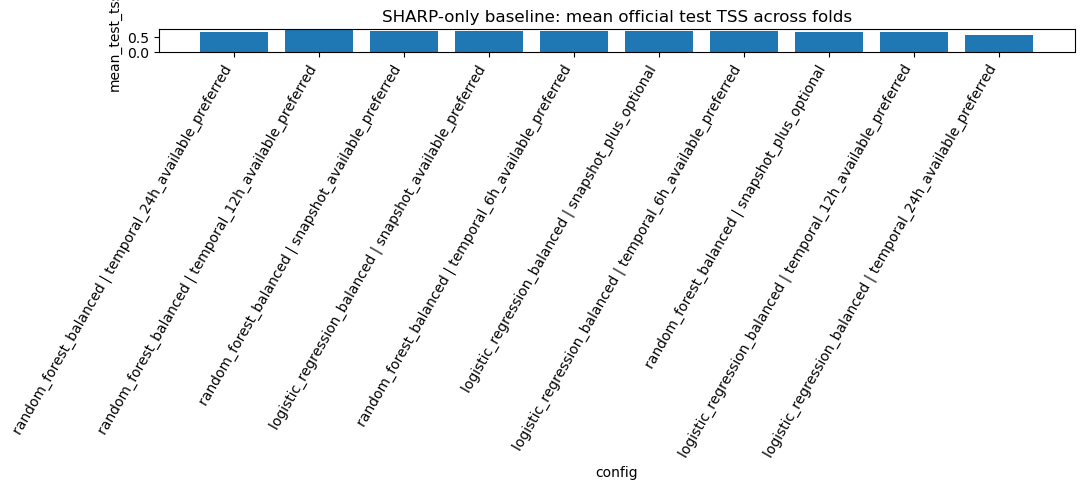

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/sharp_temporal_baseline_mean_test_tss_by_config.png


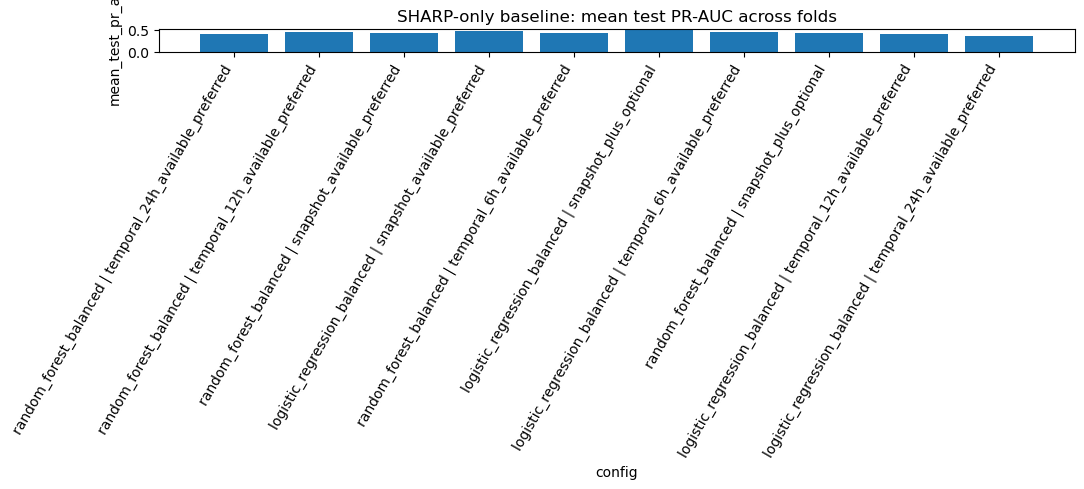

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/sharp_temporal_baseline_mean_test_pr_auc_by_config.png


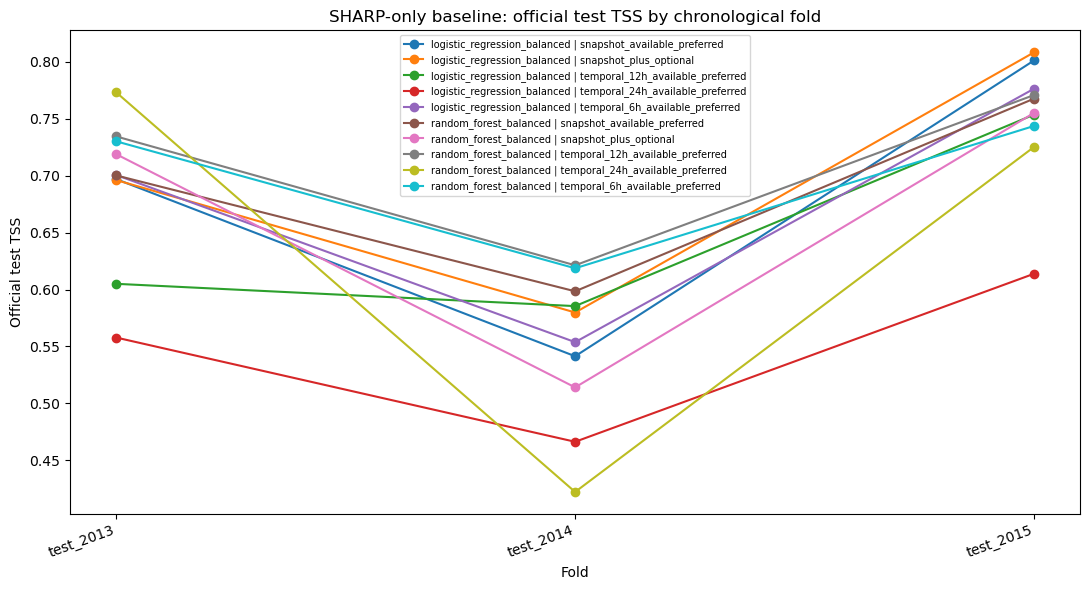

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/sharp_temporal_baseline_foldwise_test_tss.png


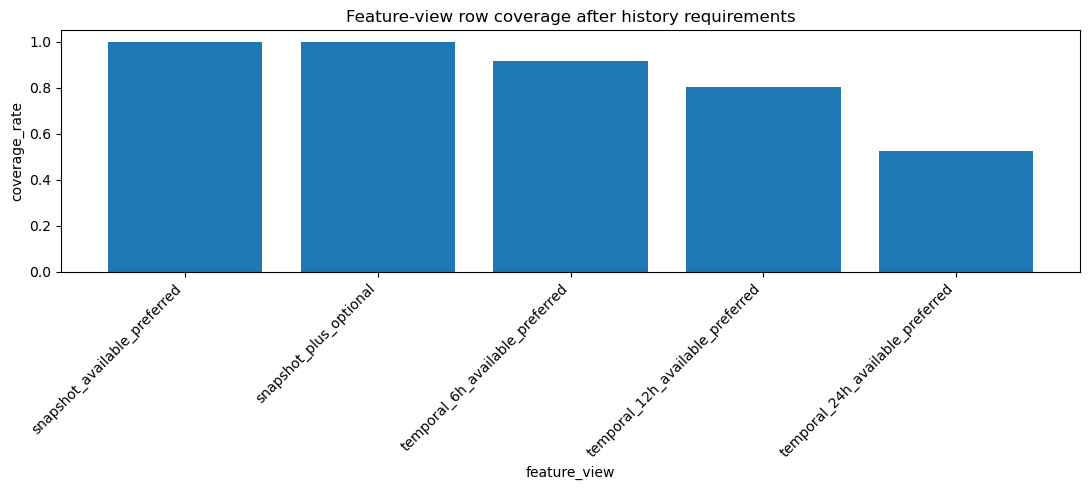

Saved: /Users/mac/Projects/solar-flare-aia-training/results/figures/sharp_temporal_baseline_feature_view_coverage.png


In [9]:
import matplotlib.pyplot as plt

def save_bar(df, x, y, title, filename, rotation=30):
    fig = plt.figure(figsize=(11, 5))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

plot_summary = summary.copy()
plot_summary["config"] = plot_summary["model_name"] + " | " + plot_summary["feature_view"]
save_bar(
    plot_summary,
    "config",
    "mean_test_tss",
    "SHARP-only baseline: mean official test TSS across folds",
    "sharp_temporal_baseline_mean_test_tss_by_config.png",
    rotation=60,
)

save_bar(
    plot_summary,
    "config",
    "mean_test_pr_auc",
    "SHARP-only baseline: mean test PR-AUC across folds",
    "sharp_temporal_baseline_mean_test_pr_auc_by_config.png",
    rotation=60,
)

fig = plt.figure(figsize=(11, 6))
for (model_name, feature_view), sub in results.sort_values("fold_id").groupby(["model_name", "feature_view"]):
    label = f"{model_name} | {feature_view}"
    plt.plot(sub["fold_id"], sub["test_tss"], marker="o", label=label)
plt.title("SHARP-only baseline: official test TSS by chronological fold")
plt.xlabel("Fold")
plt.ylabel("Official test TSS")
plt.xticks(rotation=20, ha="right")
plt.legend(fontsize=7)
plt.tight_layout()
path = FIG_DIR / "sharp_temporal_baseline_foldwise_test_tss.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", path)

ret = feature_view_summary.copy()
save_bar(
    ret,
    "feature_view",
    "coverage_rate",
    "Feature-view row coverage after history requirements",
    "sharp_temporal_baseline_feature_view_coverage.png",
    rotation=45,
)


## 9. Protocol / research log update

In [10]:
def fmt(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

best = summary.iloc[0] if len(summary) else None
best_text = "No valid model configuration was completed."
if best is not None:
    best_text = (
        f"The validation-selected SHARP-only configuration was `{best['model_name']}` "
        f"with feature view `{best['feature_view']}`. "
        f"It achieved mean validation TSS={fmt(best['mean_val_tss'])} ± {fmt(best['std_val_tss'])}, "
        f"mean official test TSS={fmt(best['mean_test_tss'])} ± {fmt(best['std_test_tss'])}, "
        f"mean test ROC-AUC={fmt(best['mean_test_roc_auc'])}, and mean test PR-AUC={fmt(best['mean_test_pr_auc'])}."
    )

protocol_text = f"""
# SHARP-only Temporal Baseline from Fusion Manifest

**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

## Scope

This notebook trained SHARP-only baselines using the AIA+SHARP+GOES fusion alignment manifest from Notebook 14.

The experiment remains **Solar Cycle 24 only**. The chronological folds use 2010–2015 data and should be interpreted as within-cycle chronological/regime testing, not Cycle 24 to Cycle 25 generalisation.

## Modality usage

- AIA image pixels were not used.
- SHARP magnetic parameters were used as input features.
- GOES was used only through the official target label lineage, `label_48h_final`.
- No GOES/XRS input features were used.

## Label

Official target: `label_48h_final`.

Embedded `.npz` labels remain ignored.

## SHARP feature set

Available preferred SHARP features:

`{[c.replace("sharp_", "") for c in available_preferred]}`

Missing preferred SHARP features:

`{missing_preferred}`

Optional SHARP features available:

`{[c.replace("sharp_", "") for c in available_optional]}`

## Feature views evaluated

`{list(feature_views.keys())}`

24h history is treated as a sensitivity feature view. 48h history was not used for first official SHARP-only baseline because Notebook 14 showed low coverage.

## Validation-selected result

{best_text}

## Evaluation protocol

For every fold and feature view:

1. Train on earlier years.
2. Validate on the year immediately before the test year.
3. Select the decision threshold using validation TSS.
4. Apply the selected threshold unchanged to the held-out test year.

Diagnostic test-best thresholds were computed only as an error-analysis reference and must not be used for official model selection.

## Next step

Use this SHARP-only branch result as the magnetic baseline before training AIA+SHARP fusion.

Recommended next notebook:

`16_aia_sharp_fusion_training_protocol.ipynb`

The first fusion experiment should compare:

1. AIA-only ResNet18 baseline.
2. SHARP-only temporal baseline.
3. Intermediate fusion: AIA image embedding + SHARP temporal/snapshot embedding.
4. Later optional GOES branch after past-only GOES/XRS feature extraction.
""".strip()

protocol_path = METRICS_DIR / "sharp_temporal_baseline_protocol.md"
research_log_path = METRICS_DIR / "sharp_temporal_baseline_research_log_update.md"

protocol_path.write_text(protocol_text, encoding="utf-8")
research_log_path.write_text(protocol_text, encoding="utf-8")

print(protocol_text)
print("\nSaved:", protocol_path)
print("Saved:", research_log_path)


# SHARP-only Temporal Baseline from Fusion Manifest

**Generated:** 2026-08-03 17:45:12

## Scope

This notebook trained SHARP-only baselines using the AIA+SHARP+GOES fusion alignment manifest from Notebook 14.

The experiment remains **Solar Cycle 24 only**. The chronological folds use 2010–2015 data and should be interpreted as within-cycle chronological/regime testing, not Cycle 24 to Cycle 25 generalisation.

## Modality usage

- AIA image pixels were not used.
- SHARP magnetic parameters were used as input features.
- GOES was used only through the official target label lineage, `label_48h_final`.
- No GOES/XRS input features were used.

## Label

Official target: `label_48h_final`.

Embedded `.npz` labels remain ignored.

## SHARP feature set

Available preferred SHARP features:

`['MEANGBZ', 'MEANGAM', 'MEANGBT', 'MEANGBH', 'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANJZH', 'ABSNJZH', 'SAVNCPP', 'MEANSHR', 'SHRGT45', 'R_VALUE', 'USFLUX', 'TOTPOT']`

Missing preferred SHARP features:

`

## 10. Final inventory

In [11]:
print("Generated metrics:")
for p in sorted(METRICS_DIR.glob("sharp_temporal_baseline_*")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("sharp_temporal_baseline_*.png")):
    print(" -", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KiB)")

print("\nFinished:", datetime.now().isoformat(timespec="seconds"))


Generated metrics:
 - results/metrics/sharp_temporal_baseline_all_results.csv (21.8 KiB)
 - results/metrics/sharp_temporal_baseline_config_summary.csv (3.7 KiB)
 - results/metrics/sharp_temporal_baseline_feature_audit.csv (1.0 KiB)
 - results/metrics/sharp_temporal_baseline_feature_view_summary.csv (1.0 KiB)
 - results/metrics/sharp_temporal_baseline_fold_data_summary.csv (1.4 KiB)
 - results/metrics/sharp_temporal_baseline_protocol.md (2.5 KiB)
 - results/metrics/sharp_temporal_baseline_research_log_update.md (2.5 KiB)
 - results/metrics/sharp_temporal_baseline_selection_summary.json (0.7 KiB)
 - results/metrics/sharp_temporal_baseline_test_predictions.csv (42809.1 KiB)
 - results/metrics/sharp_temporal_baseline_threshold_grids.csv (5501.2 KiB)

Generated figures:
 - results/figures/sharp_temporal_baseline_feature_view_coverage.png (101.3 KiB)
 - results/figures/sharp_temporal_baseline_foldwise_test_tss.png (331.8 KiB)
 - results/figures/sharp_temporal_baseline_mean_test_pr_auc_by_con